<div style="background-color:lightgreen;padding:1px 1px 1px 10px;border-radius:15px;">
    <h2><font color=blue>Follow me 프로젝트</font></h2>
</div>

---    

### 시작하기

**[선수조건]**  

* **`프로젝트 폴더 생성`**
> **`mkdir 폴더명`**  
* **`프로젝트 폴더로 이동`**
> **`cd 폴더명`**
* **`이동한 프로젝트 폴더에서 진행`**
> **`py --list`**  
> **`py -3.14 -m venv venv`**  
> **`venv\Scripts\activate`**  
> **`pip install jupyterlab`**  
> **`jupyter lab --port=10888`**  


**1단계: 패키지 설치**  

* [권장] **`Terminal`** 에서 아래와 같이 진행
> **`pip install -r requirements.txt`**



**2단계: Tello Wi-Fi 연결**
* 드론을 켜고 PC Wi-Fi를 `SW-##` 네트워크에 연결  

### 파일 설명

<span style="display:inline-block;position:left;">

| 파일 | 역할 |
|------|------|
| `requirements.txt` | 필요 패키지 목록 |
| `stage1_video.py` | 실시간 영상 스트리밍만 |
| `stage2_detection.py` | YOLO 객체 탐지 추가 |
| `stage3_tracking.py` | 객체 추적 + 드론 자율비행 |

</span>

---

In [ ]:
#Yolov8n.pt AI모델 파일 다운로드 :: 인터넷 연결 상태에서 미리 모델 다운로드
python -c "from ultralytics import YOLO; YOLO('yolov8n.pt')"

In [5]:
#YOLOv8n.pt AI 사물 검색 테스트
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
results = model('image3.jpg')


image 1/1 F:\2026 AI_SW\2026   \-(4)-2026-6-20()--followme\image3.jpg: 640x640 1 chair, 81.8ms
Speed: 3.8ms preprocess, 81.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


<div style="background-color:yellow;padding:1px 1px 1px 10px;border-radius:1px;font-color:blue;"><h2>yolov8n.pt 파일 설명</h2></div>

## Ultralytics(울트라라이틱스 기업)

  > 실시간 객체 탐지(Object Detection) AI 모델인 YOLO 시리즈(YOLOv5, YOLOv8, YOLOv11 등)를 개발하고 유지보수하는 미국의 인공지능 기업   
  > **YOLOv8 객체 탐지(Object Detection) AI 모델 가중치 파일**


* `YOLO`
  → *You Only Look Once*
* `v8`
  → YOLO 버전 8
* `n`
  → nano (가장 작은 경량 모델)
* `.pt`
  → PyTorch 모델 파일
*  **yolov8n.pt** 파일은 **이미 학습된 AI 뇌**

이 파일 안에는:

* 신경망 구조 정보
* 학습된 가중치(weight)
* 객체 인식 패턴

등이 저장되어 있음

---

## YOLOv8 모델 종류

<span style="display:inline-block;position:left;">

| 모델         | 의미          | 특징           |
| ---------- | ----------- | ------------ |
| yolov8n.pt | nano        | 가장 빠름, 가장 작음, GPU없어도 비교적 동작 가능<br>라즈베리파이/드론/엣지AI에 적합 |
| yolov8s.pt | small       | 균형형          |
| yolov8m.pt | medium      | 정확도 증가       |
| yolov8l.pt | large       | 고성능          |
| yolov8x.pt | extra large | 최고 정확도       |

</span>

---

## 주 용도는 객체 탐지

* 사람
* 자동차
* 고양이
* 드론
* 신호등

등을 화면에서 찾아냄

## 다운로드
* [Ultralytics 공식 사이트](https://www.ultralytics.com?utm_source=chatgpt.com)
* [Ultralytics GitHub](https://github.com/ultralytics/ultralytics?utm_source=chatgpt.com)

---

## .pt 파일 의미

`.pt` 는:

```text
PyTorch 모델 저장 형식
* tensor 값
* weight
* bias
* neural network parameters

```

<div style="background-color:yellow;padding:1px 1px 1px 10px;border-radius:1px;">
    <h2><font color=blue>PID 제어기 블록 다이어그램</font></h2>
</div>  

<img src=attachment:c99ba673-d5c3-4452-9bb3-1ac1d1012ef5.png border=1>

이 그림은 **PID 제어기(Proportional-Integral-Derivative Controller)** 의 구조를 보여줍니다. stage3 코드에서 직접 사용한 바로 그 제어 방식입니다.

---

### 전체 흐름

```
Setpoint(목표값) → [오차 계산] → [P + I + D 합산] → [Process] → Output(출력)
                        ↑                                              |
                        └──────────── 피드백(음수) ────────────────────┘
```

신호가 **루프를 계속 돌면서** 출력이 목표값에 가까워지도록 자동으로 조정합니다.

---

### 각 블록 상세 설명

**① Σ (합산기, 왼쪽)**

```
Error = Setpoint - Output(피드백)
```

목표값에서 현재 출력값을 빼서 **오차(Error)** 를 계산합니다. 출력이 목표보다 작으면 양수 오차, 크면 음수 오차가 됩니다.

드론 예시: 화면 중심에서 사람이 100px 오른쪽 → Error = +100

---

**② P 블록 (비례 제어)**

$$K_p \cdot e(t)$$

오차에 상수 Kp를 곱합니다. **오차가 클수록 출력이 크고, 오차가 작을수록 출력도 작아집니다.** 가장 기본적인 제어입니다.

```python
# stage3 코드
output_P = KP_YAW * err_x   # 예: 0.20 × 100px = 속도 20
```

단점: P만 쓰면 목표값에 딱 맞게 수렴하지 않고 약간 못 미치는 **정상 오차(Steady-State Error)** 가 남습니다.

---

**③ I 블록 (적분 제어)**

$$K_i \int_0^t e(\tau) d\tau$$

오차를 **시간에 걸쳐 누적(적분)** 합니다. 작은 오차가 오랫동안 지속되면 누적값이 커져서 결국 0으로 수렴시킵니다. P의 정상 오차를 제거하는 역할입니다.

```python
# 개념 코드
self._integral += error * dt
output_I = Ki * self._integral
```

단점: 드론처럼 **바람 등 외란이 있는 환경**에서는 적분값이 과도하게 누적되어 진동할 수 있습니다. 그래서 stage3에서는 Ki=0으로 설정해 PD 제어만 사용했습니다.

---

**④ D 블록 (미분 제어)**

$$K_d \cdot \frac{de(t)}{dt}$$

오차의 **변화 속도(미분)** 를 봅니다. 오차가 빠르게 줄어들고 있으면 출력을 미리 줄여서 **목표값을 지나치는 오버슈트를 방지**합니다.

```python
# stage3 코드
derivative = (error - prev_error) / dt
output_D = KD_YAW * derivative
```

드론 예시: 사람이 중앙을 향해 빠르게 오고 있다면 → D항이 회전 속도를 미리 줄여서 지나치지 않게 합니다.

---

**⑤ Σ (합산기, 오른쪽)**

```
최종 출력 = P출력 + I출력 + D출력
```

세 항의 출력을 더해서 하나의 제어 신호를 만듭니다.

```python
# stage3 PDController.compute()
output = Kp * error + Kd * derivative
# (Ki=0 이므로 I항 생략)
```

---

**⑥ Process (프로세스)**

실제 제어 대상입니다. stage3에서는 `tello.send_rc_control()`로 드론에 명령을 전송하는 부분입니다.

---

### stage3 코드와의 대응

<span style="display:inline-block;position:left;">

| 다이어그램 요소 | stage3 코드 |
|---|---|
| Setpoint | 화면 중심 좌표, TARGET_AREA |
| Error | `err_x`, `err_y`, `err_area_norm` |
| P항 | `KP_YAW * err_x` |
| D항 | `KD_YAW * derivative` |
| I항 | 생략 (드론 외란 때문에 Ki=0) |
| Process | `tello.send_rc_control()` |
| Output | 드론의 실제 위치/방향 |
| 피드백 | YOLO가 다음 프레임에서 박스 재탐지 |

</span> 

피드백 루프가 초당 약 20~30회 반복되면서 드론이 사람을 따라가게 됩니다.
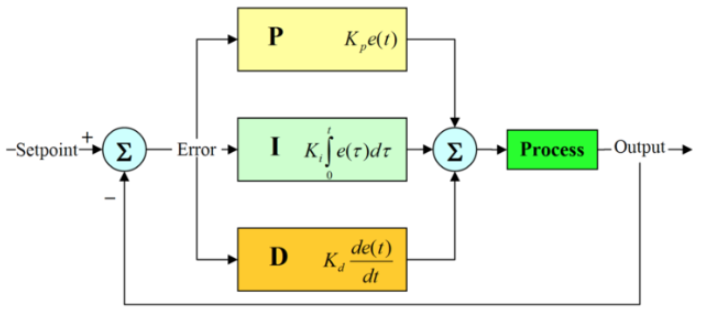